# Projet 02 — Analyse de la Qualité de l'Air

**Dataset :** UCI Air Quality Dataset (Italie, 2004–2005) , ERA5 
**Étudiant(e) :** Marie Yahaya Abdou  
**Module :** Analyse de Données avec Python — ADU 2025–2026

---

**Objectif :** Analyser les tendances de pollution, identifier les sources, prédire les pics et visualiser la distribution géographique.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium

sns.set_theme(style='whitegrid')
print('Bibliothèques importées avec succès.')

Bibliothèques importées avec succès.


## 2. Chargement du dataset

In [2]:
df = pd.read_csv('projet2.csv')
print('Dimensions :', df.shape)
df.head()

Dimensions : (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10-03-2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10-03-2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10-03-2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10-03-2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10-03-2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 3. Compréhension rapide

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9357 non-null   float64       
 1   PT08.S1(CO)    9357 non-null   float64       
 2   C6H6(GT)       9357 non-null   float64       
 3   PT08.S2(NMHC)  9357 non-null   float64       
 4   NOx(GT)        9357 non-null   float64       
 5   PT08.S3(NOx)   9357 non-null   float64       
 6   NO2(GT)        9357 non-null   float64       
 7   PT08.S4(NO2)   9357 non-null   float64       
 8   PT08.S5(O3)    9357 non-null   float64       
 9   T              9357 non-null   float64       
 10  RH             9357 non-null   float64       
 11  AH             9357 non-null   float64       
 12  Heure          9357 non-null   int32         
 13  date_only      9357 non-null   datetime64[ns]
 14  Ferie          9357 non-null   bool 

In [27]:
print(df.isnull().sum())

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Heure            0
date_only        0
Ferie            0
Type_Jour        0
Saison           0
Pic_NO2          0
NO2_futur3h      3
Pic_futur        0
Alerte           0
dtype: int64


## 4. Nettoyage des données

In [4]:
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d-%m-%Y %H:%M:%S', errors='coerce'
)

df = (df.dropna(subset=['Datetime'])
        .set_index('Datetime')
        .sort_index()
        .drop(columns=['Date', 'Time'])
        .replace(-200, np.nan)
        .drop(columns=['NMHC(GT)'], errors='ignore')
        .interpolate(method='linear')
)

print('Dataset nettoyé :', df.shape)
print('Valeurs manquantes :', df.isnull().sum().sum())

Dataset nettoyé : (9357, 12)
Valeurs manquantes : 0


## 5. Analyse exploratoire (EDA)

### 5.1 Statistiques descriptives

In [5]:
df.describe().round(2)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00
mean,2.13,1103.06,10.18,942.14,241.92,832.76,109.63,1453.30,1032.54,18.23,49.19,1.02
std,1.43,218.20,7.50,267.87,204.32,255.71,46.46,343.21,404.45,8.78,17.19,0.40
min,0.10,647.00,0.10,383.00,2.00,322.00,2.00,551.00,221.00,-1.90,9.20,0.18
25%,1.10,938.00,4.50,736.00,96.00,654.00,76.00,1227.00,733.00,11.70,35.80,0.73
50%,1.80,1067.00,8.30,910.01,180.00,804.00,104.92,1460.00,970.00,17.60,49.60,0.99
75%,2.90,1239.00,14.10,1119.00,326.00,968.00,136.31,1668.00,1293.00,24.30,62.30,1.31
max,11.90,2040.00,63.70,2214.00,1479.00,2683.00,340.00,2775.00,2523.00,44.60,88.70,2.23


### 5.2 Distribution des polluants

In [6]:
polluants = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

fig = make_subplots(rows=2, cols=2, subplot_titles=polluants)
for i, col in enumerate(polluants):
    fig.add_trace(go.Histogram(x=df[col].dropna(), nbinsx=30, name=col),
                 row=i//2+1, col=i%2+1)
fig.update_layout(title='Distribution des polluants', showlegend=False, height=500)
fig.show()

## 6. Corrélation entre les variables

In [7]:
corr = df.corr(numeric_only=True).round(2)

fig = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1, title='Matrice de corrélation de Pearson', aspect='auto')
fig.update_layout(height=520)
fig.show()

## 7. Évolution mensuelle des polluants

In [8]:
moy_mens = df[polluants].resample('ME').mean().reset_index()

fig = px.line(moy_mens, x='Datetime', y=polluants, markers=True,
             title='Évolution mensuelle des polluants',
             labels={'value': 'Concentration moyenne', 'Datetime': 'Mois', 'variable': 'Polluant'})
fig.update_layout(height=450, hovermode='x unified')
fig.show()

## 8. Pollution selon l'heure

In [9]:
df['Heure'] = df.index.hour
poll_hor = df.groupby('Heure')[polluants].mean().reset_index()

fig = px.line(poll_hor, x='Heure', y=polluants, markers=True,
             title="Concentration moyenne des polluants selon l'heure",
             labels={'value': 'Concentration moyenne', 'variable': 'Polluant'})
fig.update_layout(height=430, hovermode='x unified',
                  xaxis=dict(tickmode='linear', dtick=2))
fig.show()

## 9. Température et pollution

In [10]:
df_s = df[['T', 'NO2(GT)']].dropna().iloc[::3]

fig = px.scatter(df_s, x='T', y='NO2(GT)', opacity=0.4, trendline='ols',
                title='Relation entre température et NO2',
                labels={'T': 'Température (°C)', 'NO2(GT)': 'NO2 (µg/m³)'})
fig.update_traces(marker_color='#185FA5', selector=dict(mode='markers'))
fig.update_layout(height=430)
fig.show()

## 10. Comparaison semaine / week-end / jours fériés

C:\Users\Tninkpad\AppData\Local\Temp\ipykernel_4488\3205149025.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type_Jour', y='NO2(GT)',


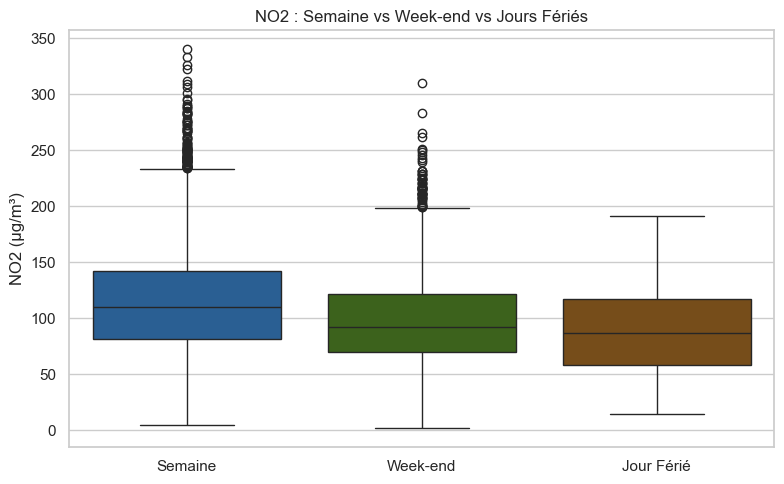

            CO(GT)  NOx(GT)  NO2(GT)
Type_Jour                           
Jour Férié    1.87   196.42    89.17
Semaine       2.29   260.31   114.61
Week-end      1.74   199.31    98.94


In [11]:
jours_feries = pd.to_datetime([
    '2004-04-25','2004-05-01','2004-06-02','2004-06-24','2004-08-15',
    '2004-11-01','2004-12-08','2004-12-25','2004-12-26',
    '2005-01-01','2005-01-06','2005-04-25'
])

df['date_only'] = pd.to_datetime(df.index.date)
df['Ferie']     = df['date_only'].isin(jours_feries)
df['Type_Jour'] = np.where(df['Ferie'], 'Jour Férié',
                  np.where(df.index.dayofweek >= 5, 'Week-end', 'Semaine'))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Type_Jour', y='NO2(GT)',
            order=['Semaine','Week-end','Jour Férié'],
            palette={'Semaine':'#185FA5','Week-end':'#3B6D11','Jour Férié':'#854F0B'}, ax=ax)
ax.set_title('NO2 : Semaine vs Week-end vs Jours Fériés')
ax.set_xlabel('')
ax.set_ylabel('NO2 (µg/m³)')
plt.tight_layout()
plt.show()

print(df.groupby('Type_Jour')[['CO(GT)','NOx(GT)','NO2(GT)']].mean().round(2))

## 11. Analyse saisonnière

In [12]:
df['Saison'] = pd.cut(df.index.month, bins=[0,3,6,9,12],
                      labels=['Hiver','Printemps','Été','Automne'])

saison_moy = df.groupby('Saison', observed=True)[polluants].mean().round(2).reset_index()

fig = px.bar(
    saison_moy.melt(id_vars='Saison', var_name='Polluant', value_name='Concentration'),
    x='Saison', y='Concentration', color='Polluant', barmode='group',
    title='Concentration moyenne des polluants par saison',
    labels={'Concentration': 'Concentration moyenne', 'Saison': ''}
)
fig.update_layout(height=430, hovermode='x unified')
fig.show()

## 12. Seuils OMS — Jours dangereux

In [13]:
SEUIL_NO2 = 200


heures_dep = (df['NO2(GT)'] > SEUIL_NO2).sum()
pourcentage = 100 * heures_dep / len(df)

print(f'Heures > {SEUIL_NO2} µg/m³ : {heures_dep}')
print(f'Pourcentage : {pourcentage:.1f}%')


no2_daily = df['NO2(GT)'].resample('D').max().reset_index()
no2_daily['Alerte'] = no2_daily['NO2(GT)'] > SEUIL_NO2

print(f'Jours dangereux : {no2_daily["Alerte"].sum()}')


fig = px.bar(
    no2_daily,
    x='Datetime',
    y='NO2(GT)',
    color='Alerte',
    title=f'NO2 journalier max — seuil {SEUIL_NO2} µg/m³'
)

fig.add_hline(
    y=SEUIL_NO2,
    line_dash='dash'
)

fig.show()

Heures > 200 µg/m³ : 387
Pourcentage : 4.1%
Jours dangereux : 87


## 13. Conditions météo lors des pics de pollution

In [14]:
df['Pic_NO2'] = df['NO2(GT)'] > 150


comparaison = df.groupby('Pic_NO2')[
    ['T', 'RH', 'CO(GT)', 'NOx(GT)']
].mean().round(2)

print(comparaison)


fig = px.scatter(
    df[['T', 'NO2(GT)', 'Pic_NO2']].dropna(),
    x='T',
    y='NO2(GT)',
    color='Pic_NO2',
    opacity=0.4,
    title='Température vs NO2'
)

fig.add_hline(y=150, line_dash='dash')
fig.show()

             T     RH  CO(GT)  NOx(GT)
Pic_NO2                               
False    18.94  49.51    1.80   183.66
True     15.00  47.72    3.65   510.51


## 14. Système d'alerte préventive (horizon 3h)

In [15]:

df['NO2_futur3h'] = df['NO2(GT)'].shift(-3)
df['Pic_futur'] = df['NO2_futur3h'] > 150


stats = df.groupby('Pic_futur')[['T', 'NOx(GT)']].mean()

T_seuil = stats.loc[True, 'T']
NOx_seuil = stats.loc[True, 'NOx(GT)']

print(f"Règle d'alerte : T < {T_seuil:.1f}°C et NOx > {NOx_seuil:.0f}")


df['Alerte'] = (df['T'] < T_seuil) & (df['NOx(GT)'] > NOx_seuil)


vrais_positifs = (df['Alerte'] & df['Pic_futur']).sum()

precision = 100 * vrais_positifs / df['Alerte'].sum()
rappel = 100 * vrais_positifs / df['Pic_futur'].sum()

print(f"Précision : {precision:.1f}%")
print(f"Rappel    : {rappel:.1f}%")

Règle d'alerte : T < 14.8°C et NOx > 422
Précision : 57.9%
Rappel    : 28.5%


## 15. Test t de Student (Semaine vs Week-end)

In [16]:
from scipy import stats

no2_sem = df[df['Type_Jour']=='Semaine']['NO2(GT)'].dropna()
no2_we  = df[df['Type_Jour']=='Week-end']['NO2(GT)'].dropna()
t, p    = stats.ttest_ind(no2_sem, no2_we)

print(f'Semaine : {no2_sem.mean():.2f} µg/m³  |  Week-end : {no2_we.mean():.2f} µg/m³')
print(f't = {t:.3f}   p = {p:.6f}')
print('→ Différence significative (p < 0.05)' if p < 0.05 else '→ Non significatif')

Semaine : 114.61 µg/m³  |  Week-end : 98.94 µg/m³
t = 14.585   p = 0.000000
→ Différence significative (p < 0.05)


## 15b. Intégration des données météo ERA5 (Open-Meteo)

In [17]:
import urllib.request
import json


url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=45.4654&longitude=9.1859"
    "&start_date=2004-03-10&end_date=2005-02-28"
    "&hourly=wind_speed_10m,wind_direction_10m,"
    "precipitation,surface_pressure,boundary_layer_height"
    "&timezone=Europe/Rome"
)

with urllib.request.urlopen(url) as response:
    data = json.loads(response.read())


df_era5 = pd.DataFrame(data['hourly'])

df_era5['time'] = pd.to_datetime(df_era5['time'])
df_era5 = df_era5.set_index('time')


df_era5.rename(columns={
    'wind_speed_10m': 'wind_speed',
    'wind_direction_10m': 'wind_dir',
    'surface_pressure': 'pressure',
    'boundary_layer_height': 'blh'
}, inplace=True)


df_merged = df.join(df_era5, how='left')


colonnes_meteo = [
    'wind_speed',
    'wind_dir',
    'precipitation',
    'pressure',
    'blh'
]

df_merged[colonnes_meteo] = (
    df_merged[colonnes_meteo]
    .interpolate()
)

print("Dataset fusionné :", df_merged.shape)

df_merged[['wind_speed', 'pressure', 'blh']].describe().round(2)

Dataset fusionné : (9357, 26)


,wind_speed,pressure,blh
count,9357.00,9357.00,9357.00
mean,6.21,999.08,388.38
std,3.58,7.56,523.62
min,0.00,971.70,10.00
25%,3.90,994.80,60.00
50%,5.80,998.40,125.00
75%,7.30,1003.80,520.00
max,36.30,1019.90,2970.00


In [18]:

era5_cols = [
    'wind_speed',
    'wind_dir',
    'precipitation',
    'pressure',
    'blh'
]


corr = df_merged[era5_cols + ['NO2(GT)']].corr()['NO2(GT)']
corr = corr.drop('NO2(GT)').round(3)


fig = px.bar(
    corr.sort_values(),
    orientation='h',
    title='Corrélation des variables ERA5 avec NO2',
    labels={
        'value': 'Corrélation',
        'index': 'Variable météo'
    }
)

fig.add_vline(x=0, line_dash='dash')
fig.show()


variable_max = corr.abs().idxmax()

print(
    f"Facteur le plus corrélé avec NO2 : "
    f"{variable_max} (r = {corr[variable_max]:.3f})"
)

Facteur le plus corrélé avec NO2 : pressure (r = 0.141)


## 16. Prédiction du NO2 à 6h — Comparaison de 4 modèles

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score


df_merged['JourSemaine'] = df_merged.index.dayofweek
df_merged['Mois_num'] = df_merged.index.month
df_merged['Heure'] = df_merged.index.hour
df_merged['NO2_lag1'] = df_merged['NO2(GT)'].shift(1)
df_merged['NO2_lag6'] = df_merged['NO2(GT)'].shift(6)


df_merged['NO2_cible6h'] = df_merged['NO2(GT)'].shift(-6)

features = [
    'Heure', 'JourSemaine', 'Mois_num',
    'T', 'RH', 'CO(GT)', 'NOx(GT)',
    'NO2_lag1', 'NO2_lag6',
    'wind_speed', 'wind_dir',
    'precipitation', 'pressure', 'blh'
]


df_ml = df_merged[features + ['NO2_cible6h']].dropna()

X = df_ml[features]
y = df_ml['NO2_cible6h']

split = int(len(df_ml) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)


lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


resultats = pd.DataFrame({
    'Modèle': [
        'Régression Linéaire',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        round(mean_absolute_error(y_test, lr.predict(X_test)), 2),
        round(mean_absolute_error(y_test, rf.predict(X_test)), 2),
        round(mean_absolute_error(y_test, xgb.predict(X_test)), 2)
    ],
    'R²': [
        round(r2_score(y_test, lr.predict(X_test)), 3),
        round(r2_score(y_test, rf.predict(X_test)), 3),
        round(r2_score(y_test, xgb.predict(X_test)), 3)
    ]
})

print("=== Comparaison — Prédiction NO2 à 6h avec ERA5 ===")
print(resultats.to_string(index=False))

=== Comparaison — Prédiction NO2 à 6h avec ERA5 ===
             Modèle   MAE     R²
Régression Linéaire 42.70 -0.012
      Random Forest 33.83  0.332
            XGBoost 36.02  0.222


## 17. Réel vs Prédit & Importance des variables

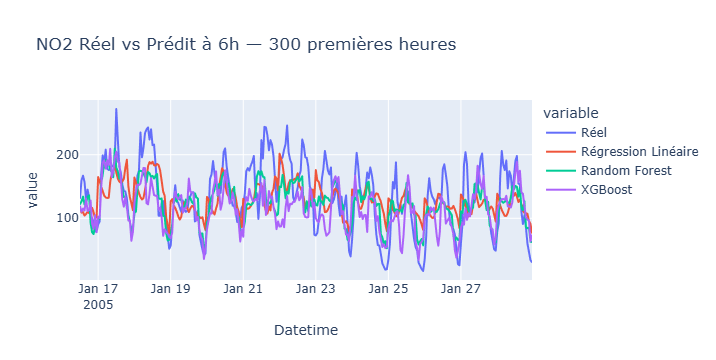

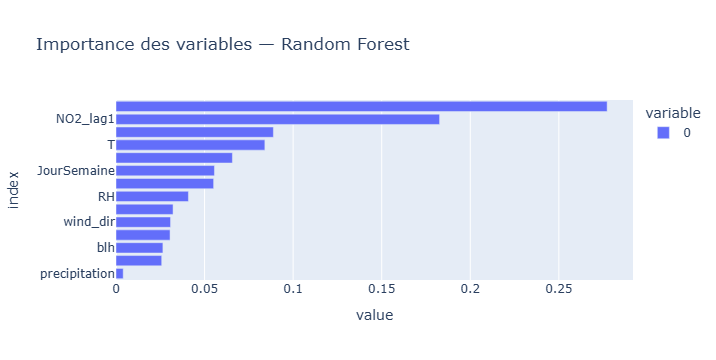

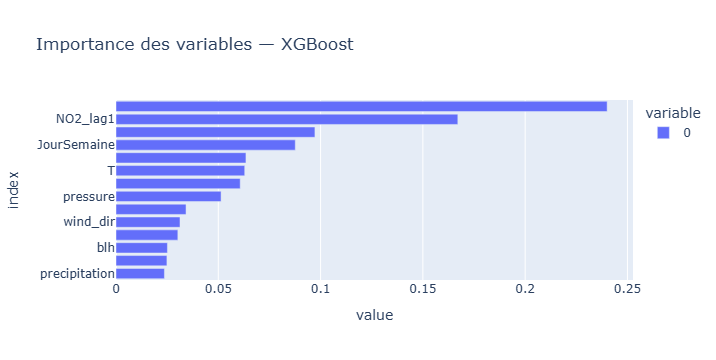

In [25]:
n = 300

df_pred = pd.DataFrame({
    'Réel': y_test.iloc[:n],
    'Régression Linéaire': lr.predict(X_test)[:n],
    'Random Forest': rf.predict(X_test)[:n],
    'XGBoost': xgb.predict(X_test)[:n]
})

fig = px.line(
    df_pred,
    title='NO2 Réel vs Prédit à 6h — 300 premières heures'
)

fig.show()


importance_rf = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values()

fig = px.bar(
    importance_rf,
    orientation='h',
    title='Importance des variables — Random Forest'
)

fig.show()


importance_xgb = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values()

fig = px.bar(
    importance_xgb,
    orientation='h',
    title='Importance des variables — XGBoost'
)

fig.show()

## 18. Carte géospatiale interactive — Stations italiennes

In [21]:
stations = pd.DataFrame({
    'Ville': ['Milan (UCI)', 'Turin', 'Rome', 'Florence', 'Bologne', 'Naples'],
    'Lat': [45.4654, 45.0703, 41.9028, 43.7696, 44.4949, 40.8518],
    'Lon': [9.1859, 7.6869, 12.4964, 11.2558, 11.3426, 14.2681],
    'NO2_mean': [df['NO2(GT)'].mean().round(1), 98.4, 76.2, 64.8, 87.3, 71.5]
})

carte = folium.Map(location=[43.5, 11.5], zoom_start=6)

for _, ville in stations.iterrows():

    if ville['NO2_mean'] < 70:
        couleur = 'green'
    elif ville['NO2_mean'] < 90:
        couleur = 'orange'
    else:
        couleur = 'red'

    folium.CircleMarker(
        location=[ville['Lat'], ville['Lon']],
        radius=ville['NO2_mean'] / 7,
        color=couleur,
        fill=True,
        popup=f"{ville['Ville']} : {ville['NO2_mean']} µg/m³"
    ).add_to(carte)

carte